# Transport Maps and Acceptance–Rejection Sampling

Author: Fred J. Hickernell

How can easy proposal draws become unweighted samples from a target distribution? 

* A transport map moves every draw
* Acceptance–rejection keeps selected draws unchanged.

We compare these constructions for a Beta$(2,1)$ target, then explore two different curved bivariate targets.

Use Jupyter with the `qmcpy` environment described in the [MATH 565 repository](https://github.com/fjhickernell/MATH565Fall2026), or open a private working copy in Google Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/sampling/TransportMapsAndAcceptanceRejection.ipynb)

In Colab, run the setup cell below once and then continue in order. It installs the course's recorded `classlib` and QMCPy versions plus TeX support, which may take several minutes. Colab does not save changes back to the course repository; use **File → Save a copy in Drive** if you want to keep your work.


In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.integrate import quad
from scipy.special import erf
import classlib as cl

%matplotlib inline

cl.nbviz.init(use_tex=True)
colors = cl.nbviz.TOL_BRIGHT
rng = np.random.default_rng()  # Fresh realizations on each run


## Transport maps

Let $Z$ have proposal density $\varrho_{\mathrm{prop}}$ and let $X=T(Z)$. For an invertible differentiable map, the change-of-variables formula gives

\begin{align*}
\varrho_{\mathrm{tar}}(T(z))\left|\det\nabla T(z)\right|
&=\varrho_{\mathrm{prop}}(z).
\end{align*}

Here the target density is normalized. The map moves the proposal's probability mass to the target; every proposal draw produces one target draw.

### A scalar transport: uniform to Beta$(2,1)$

Take $Z\sim\operatorname{Unif}(0,1)$ and target density $\varrho_{\mathrm{tar}}(x)=2x$ on $(0,1)$, zero elsewhere. Its CDF is $F_X(x)=x^2$ on $[0,1]$, so

\begin{align*}
X=T(Z)=\sqrt Z,\qquad
\mathbb P(X\le x)&=\mathbb P(Z\le x^2)=x^2,\quad 0\le x\le1,\\
\varrho_{\mathrm{tar}}(T(z))T'(z)
&=2\sqrt z\,\frac{1}{2\sqrt z}=1
=\varrho_{\mathrm{prop}}(z),\quad 0<z<1.
\end{align*}

The derivative is unbounded at zero, but the identity holds on the interior and the endpoint has probability zero. The increasing map pushes points toward the high-density end of the interval.


Sample mean: 0.6674; target mean: 0.6667


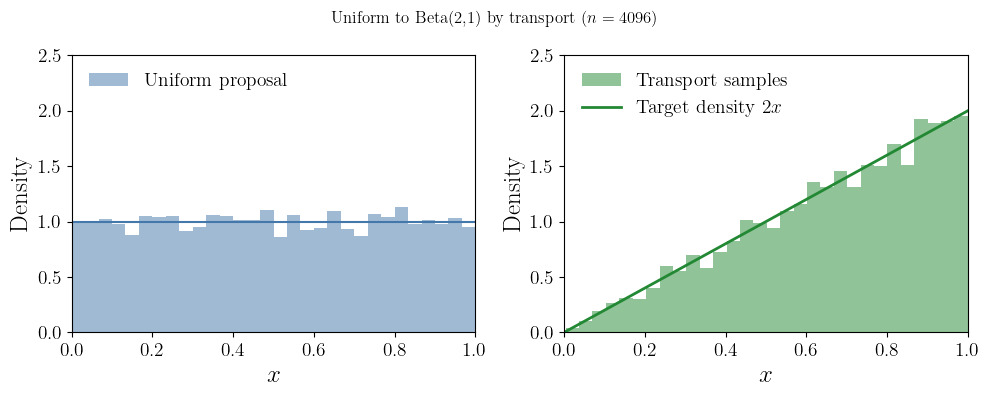

In [3]:
n = 4096
z = rng.random(n)
x_transport = np.sqrt(z)
scalar_grid = np.linspace(0, 1, 401)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(z, bins=30, density=True, alpha=0.5,
             color=colors["blue"], label="Uniform proposal")
axes[0].plot(scalar_grid, np.ones_like(scalar_grid), color=colors["blue"])
axes[1].hist(x_transport, bins=30, density=True, alpha=0.5,
             color=colors["green"], label="Transport samples")
axes[1].plot(scalar_grid, 2 * scalar_grid, color=colors["green"],
             lw=2, label=r"Target density $2x$")
for ax in axes:
    ax.set(xlabel="$x$", ylabel="Density", xlim=(0, 1), ylim=(0, 2.5))
    ax.legend(loc="upper left")
fig.suptitle(f"Uniform to Beta(2,1) by transport ($n={n}$)")
plt.tight_layout()

interior = np.linspace(0.001, 0.999, 1000)
jacobian_product = 2 * np.sqrt(interior) / (2 * np.sqrt(interior))
assert np.allclose(jacobian_product, 1)
print(f"Sample mean: {x_transport.mean():.4f}; target mean: {2 / 3:.4f}")


### A triangular transport on $\mathbb R^2$

Let $Z_1,Z_2$ be independent standard normal variables. Starting with independent uniforms, one can obtain them as $Z_j=\Phi^{-1}(U_j)$. For $b>0$, set

\begin{align*}
X_1&=Z_1,& X_2&=Z_2+b(Z_1^2-1),\\
T_b^{-1}(x_1,x_2)&=(x_1,x_2-b(x_1^2-1)),&
\nabla T_b(z)&=\begin{pmatrix}1&0\\2bz_1&1\end{pmatrix}.
\end{align*}

The Jacobian determinant is one. With $\phi$ the standard normal PDF, the normalized target density and conditional mean are

\begin{align*}
\varrho_{\mathrm{tar}}(x_1,x_2)
&=\phi(x_1)\phi(x_2-b(x_1^2-1)),\\
\mathbb E(X_2\mid X_1=x_1)&=b(x_1^2-1).
\end{align*}

This target has support on all of $\mathbb R^2$. It is different from the bounded banana-shaped example used later. The curved conditional mean reveals dependence even though $\operatorname{Cov}(X_1,X_2)=0$.


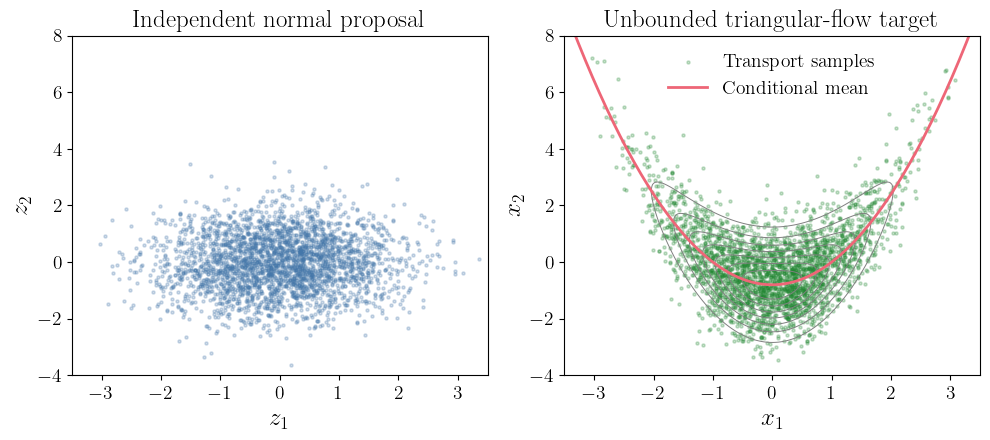

In [4]:
flow_b = 0.8
n_flow = 3000
flow_z = rng.standard_normal((n_flow, 2))
flow_x = flow_z.copy()
flow_x[:, 1] += flow_b * (flow_z[:, 0] ** 2 - 1)

flow_x1 = np.linspace(-3.5, 3.5, 180)
flow_x2 = np.linspace(-4, 8, 220)
flow_grid1, flow_grid2 = np.meshgrid(flow_x1, flow_x2)
flow_density = (stats.norm.pdf(flow_grid1)
                * stats.norm.pdf(flow_grid2 - flow_b * (flow_grid1 ** 2 - 1)))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].scatter(flow_z[:, 0], flow_z[:, 1], s=5, alpha=0.25, color=colors["blue"])
axes[0].set(title="Independent normal proposal", xlabel="$z_1$", ylabel="$z_2$")
axes[1].contour(flow_grid1, flow_grid2, flow_density, levels=8,
                colors="gray", linewidths=0.7)
axes[1].scatter(flow_x[:, 0], flow_x[:, 1], s=5, alpha=0.25,
                color=colors["green"], label="Transport samples")
axes[1].plot(flow_x1, flow_b * (flow_x1 ** 2 - 1), color=colors["red"],
             lw=2, label="Conditional mean")
axes[1].set(title="Unbounded triangular-flow target",
            xlabel="$x_1$", ylabel="$x_2$")
axes[1].legend(loc="upper center")
for ax in axes:
    ax.set(xlim=(-3.5, 3.5), ylim=(-4, 8))
plt.tight_layout()


Recovering the proposal coordinates tests the inverse map. The density identity supplies a separate check: the target density at each transformed point should equal the proposal density because the determinant is one.


In [5]:
recovered_z = flow_x.copy()
recovered_z[:, 1] -= flow_b * (flow_x[:, 0] ** 2 - 1)
assert np.allclose(recovered_z, flow_z)
proposal_log_density = stats.norm.logpdf(flow_z).sum(axis=1)
target_log_density = (stats.norm.logpdf(flow_x[:, 0])
                      + stats.norm.logpdf(flow_x[:, 1]
                                          - flow_b * (flow_x[:, 0] ** 2 - 1)))
assert np.allclose(target_log_density, proposal_log_density)
print(f"Largest inverse-map error: {np.max(np.abs(recovered_z - flow_z)):.2e}")
print(f"Sample variance of X2: {flow_x[:, 1].var():.3f}; "
      f"target variance: {1 + 2 * flow_b ** 2:.3f}")


Largest inverse-map error: 6.38e-16
Sample variance of X2: 2.133; target variance: 2.280


## Acceptance–rejection sampling

### Keep selected proposal draws

A useful transport is not always available. Instead, let the desired density be $c\varrho_{\mathrm{tar}}$, where $\varrho_{\mathrm{tar}}$ may be unnormalized and

\begin{align*}
c^{-1}&=\int\varrho_{\mathrm{tar}}(x)\,\mathrm dx.
\end{align*}

Choose a normalized proposal density $\varrho_{\mathrm{prop}}$ and prove an envelope bound

\begin{align*}
\varrho_{\mathrm{tar}}(z)&\le M\varrho_{\mathrm{prop}}(z)
\quad\text{for all }z.
\end{align*}

The proposal must cover the target's support. Draw $Z\sim\varrho_{\mathrm{prop}}$ and an independent $U\sim\operatorname{Unif}(0,1)$, and accept $Z$ when

\begin{align*}
U\le\frac{\varrho_{\mathrm{tar}}(Z)}{M\varrho_{\mathrm{prop}}(Z)}.
\end{align*}

Rejected draws are discarded; repeat until $n$ accepted draws have been collected. With independent proposal/decision pairs, the accepted samples are IID. The unknown normalizing constant $c$ is not needed by the algorithm.

### Why the accepted density is correct

Let $W$ indicate acceptance. Bayes' conditional-density formula gives

\begin{align*}
\varrho_{Z\mid W}(z\mid1)
&=\frac{\mathbb P(W=1\mid Z=z)\varrho_{\mathrm{prop}}(z)}{\mathbb P(W=1)}\\
&=\frac{\varrho_{\mathrm{tar}}(z)}{M\mathbb P(W=1)}
=c\varrho_{\mathrm{tar}}(z),\\
\mathbb P(W=1)&=\frac{1}{Mc}.
\end{align*}

Thus $Mc$ is the expected number of proposals per accepted sample. A larger valid $M$ lowers efficiency; an $M$ that violates the bound can produce the wrong distribution.


### The same Beta$(2,1)$ target

For the uniform proposal, $\varrho_{\mathrm{prop}}(z)=1$ on $(0,1)$, while $\varrho_{\mathrm{tar}}(z)=2z$ and $c=1$. We may take $M=2$, giving

\begin{align*}
U\le Z,\qquad \mathbb P(W=1)=\tfrac12.
\end{align*}

In the plot, points below the diagonal are accepted. Transport moves every $Z$ to $\sqrt Z$; acceptance–rejection retains selected $Z$ values without moving them.


Observed acceptance fraction: 0.506; theory: 0.500


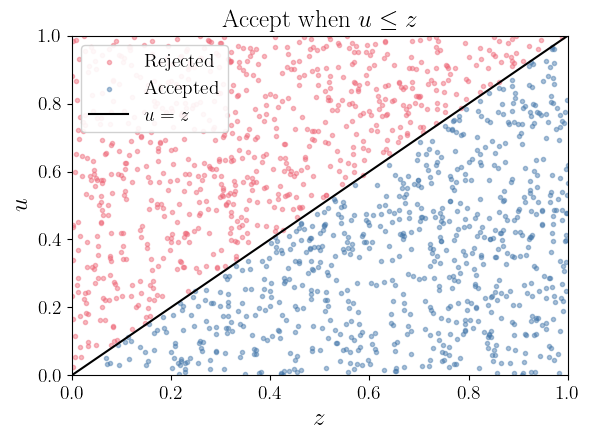

In [6]:
n_proposals_demo = 1500
z_demo = rng.random(n_proposals_demo)
u_demo = rng.random(n_proposals_demo)
w_demo = u_demo <= z_demo
fig, ax = plt.subplots(figsize=(6, 4.5))
for keep, label, color in [(False, "Rejected", colors["red"]),
                            (True, "Accepted", colors["blue"])]:
    mask = w_demo == keep
    ax.scatter(z_demo[mask], u_demo[mask], s=9, alpha=0.45, color=color, label=label)
ax.plot([0, 1], [0, 1], color="black", label="$u=z$")
ax.set(xlabel="$z$", ylabel="$u$", title="Accept when $u\le z$", xlim=(0, 1), ylim=(0, 1))
ax.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9)
plt.tight_layout()
print(f"Observed acceptance fraction: {w_demo.mean():.3f}; theory: 0.500")


Use `cl.sampling.accept_reject` for a requested number of accepted samples. Supply log densities so the acceptance comparison can be made without multiplying very small densities. The SciPy Beta and uniform distributions also enforce the support.

The shared sampler works in batches and discards any surplus accepted points in the final batch. Its reported `final_accept_rate` is the number **returned** divided by all proposals, so it can be lower than the intrinsic acceptance probability. The fixed-proposal experiment above counts every accepted proposal.


Transport: 4096 proposals for 4096 samples
Acceptance–rejection: 8264 proposals for 4096 samples
Returned samples / proposals: 0.496


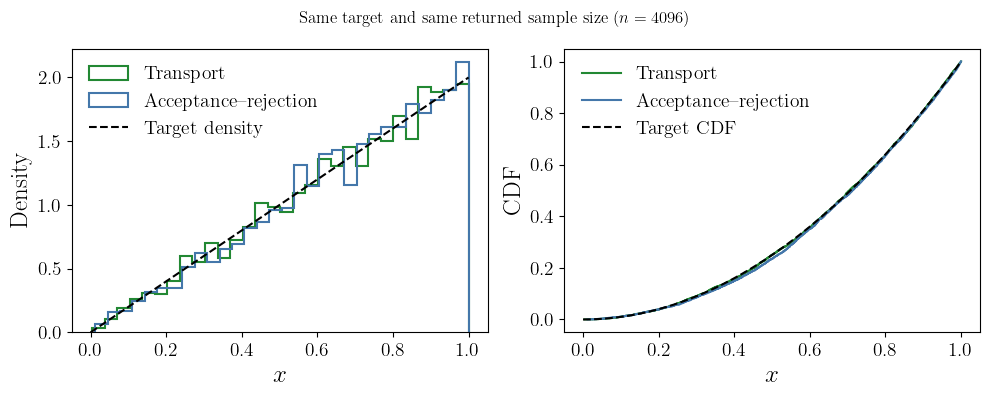

In [7]:
def uniform_scalar_proposal(n, rng):
    return rng.random((n, 1))


beta_samples, beta_info = cl.sampling.accept_reject(
    log_target_density=lambda points: stats.beta.logpdf(points[:, 0], 2, 1),
    proposal_sampler=uniform_scalar_proposal,
    log_prop_density=lambda points: stats.uniform.logpdf(points[:, 0]),
    M=2,
    n_samples=n,
    rng=rng,
)
beta_samples = beta_samples[:, 0]
assert beta_samples.shape == (n,)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for values, label, color in [(x_transport, "Transport", colors["green"]),
                              (beta_samples, "Acceptance–rejection", colors["blue"])]:
    axes[0].hist(values, bins=30, density=True, histtype="step", lw=1.5,
                 color=color, label=label)
    ordered = np.sort(values)
    axes[1].step(ordered, np.arange(1, n + 1) / n, where="post", color=color, label=label)
axes[0].plot(scalar_grid, 2 * scalar_grid, "k--", label="Target density")
axes[1].plot(scalar_grid, scalar_grid ** 2, "k--", label="Target CDF")
axes[0].set(xlabel="$x$", ylabel="Density")
axes[1].set(xlabel="$x$", ylabel="CDF")
for ax in axes:
    ax.legend(loc="upper left")
fig.suptitle(f"Same target and same returned sample size ($n={n}$)")
plt.tight_layout()
print(f"Transport: {n} proposals for {n} samples")
print(f"Acceptance–rejection: {beta_info['proposed']} proposals for {n} samples")
print(f"Returned samples / proposals: {beta_info['final_accept_rate']:.3f}")


### A bounded banana-shaped target on $[0,1]^2$

This example is adapted from the Fall 2025 acceptance–rejection notebook. On the unit square, define

\begin{align*}
\varrho_{\mathrm{tar}}(x_1,x_2)
&=\exp\left[-a(1-x_1)^2-b(x_2-x_1^2)^2\right],
& a&=2,\quad b=60,
\end{align*}

and set it to zero elsewhere. Its ridge follows $x_2=x_1^2$. Unlike the triangular-flow target, this density is **bounded to the unit square** and is not supplied with its normalizing constant.

Use a uniform proposal on $[0,1]^2$, whose density there is one. Both terms in the exponent are nonpositive, so $\varrho_{\mathrm{tar}}\le1$: $M=1$ is a valid global bound. The acceptance rule is simply $U\le\varrho_{\mathrm{tar}}(Z)$.


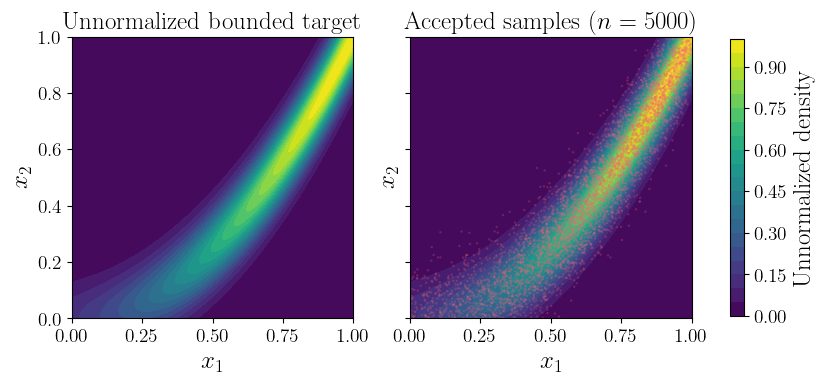

In [8]:
banana_a, banana_b = 2.0, 60.0


def log_banana(points):
    x1, x2 = points[:, 0], points[:, 1]
    inside = (x1 >= 0) & (x1 <= 1) & (x2 >= 0) & (x2 <= 1)
    result = np.full(len(points), -np.inf)
    result[inside] = (-banana_a * (1 - x1[inside]) ** 2
                      - banana_b * (x2[inside] - x1[inside] ** 2) ** 2)
    return result


def uniform_square_proposal(n, rng):
    return rng.random((n, 2))


def log_uniform_square(points):
    inside = np.all((points >= 0) & (points <= 1), axis=1)
    return np.where(inside, 0.0, -np.inf)


n_banana = 5000
banana_samples, banana_info = cl.sampling.accept_reject(
    log_target_density=log_banana,
    proposal_sampler=uniform_square_proposal,
    log_prop_density=log_uniform_square,
    M=1,
    n_samples=n_banana,
    rng=rng,
)
assert banana_samples.shape == (n_banana, 2)
assert np.all((banana_samples >= 0) & (banana_samples <= 1))

banana_grid = np.linspace(0, 1, 180)
grid1, grid2 = np.meshgrid(banana_grid, banana_grid)
banana_density = np.exp(log_banana(np.column_stack([grid1.ravel(), grid2.ravel()])))
banana_density = banana_density.reshape(grid1.shape)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for ax in axes:
    contours = ax.contourf(grid1, grid2, banana_density, levels=20, cmap="viridis")
    ax.set(xlabel="$x_1$", ylabel="$x_2$", xlim=(0, 1), ylim=(0, 1), aspect="equal")
axes[0].set_title("Unnormalized bounded target")
axes[1].scatter(banana_samples[:, 0], banana_samples[:, 1], s=3,
                color=colors["red"], alpha=0.25, edgecolor="none")
axes[1].set_title(f"Accepted samples ($n={n_banana}$)")
fig.colorbar(contours, ax=axes, label="Unnormalized density", shrink=0.8)
plt.show()


### Check the bounded target and acceptance probability

Numerical integration supplies a benchmark, not an input to the sampler. Write $A=\int_{[0,1]^2}\varrho_{\mathrm{tar}}(x)\,\mathrm dx=1/c$. Because $M=1$, the intrinsic acceptance probability is $A$. Integrating over one coordinate also gives normalized marginal densities for comparison with histograms.

We integrate over $x_2$ analytically using the error function, then use one-dimensional quadrature. A separate fixed batch estimates the acceptance probability without the final-batch truncation of the shared sampler.


Quadrature acceptance probability: 0.1257
Fixed-batch observed acceptance: 0.1231
Standard error of this fraction: 0.0023
Returned samples / proposals: 0.1260
Expected proposals per accepted sample: 7.95


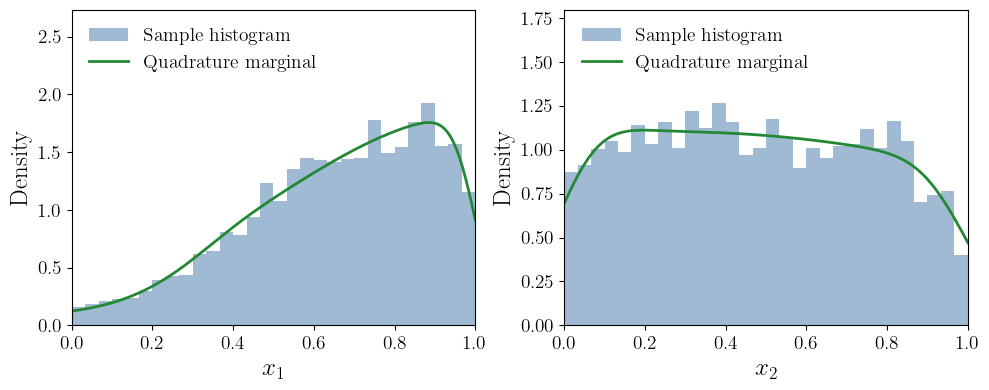

In [9]:
def banana_x1_unnormalized(x1):
    root_b = np.sqrt(banana_b)
    integral_x2 = (np.sqrt(np.pi) / (2 * root_b)
                    * (erf(root_b * (1 - x1 ** 2)) + erf(root_b * x1 ** 2)))
    return np.exp(-banana_a * (1 - x1) ** 2) * integral_x2


banana_mass, quadrature_error = quad(banana_x1_unnormalized, 0, 1, epsabs=1e-11)
banana_x1_density = banana_x1_unnormalized(banana_grid) / banana_mass
banana_x2_density = np.array([
    quad(lambda x1: np.exp(-banana_a * (1 - x1) ** 2
                           - banana_b * (x2 - x1 ** 2) ** 2), 0, 1)[0]
    / banana_mass for x2 in banana_grid
])

n_check = 20000
check_z = uniform_square_proposal(n_check, rng)
check_w = np.log(rng.random(n_check)) <= log_banana(check_z)
print(f"Quadrature acceptance probability: {banana_mass:.4f}")
print(f"Fixed-batch observed acceptance: {check_w.mean():.4f}")
print(f"Standard error of this fraction: {np.sqrt(banana_mass * (1 - banana_mass) / n_check):.4f}")
print(f"Returned samples / proposals: {banana_info['final_accept_rate']:.4f}")
print(f"Expected proposals per accepted sample: {1 / banana_mass:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for j, (ax, density) in enumerate(zip(axes, [banana_x1_density, banana_x2_density])):
    ax.hist(banana_samples[:, j], bins=30, density=True, alpha=0.5,
            color=colors["blue"], label="Sample histogram")
    ax.plot(banana_grid, density, color=colors["green"], lw=2,
            label="Quadrature marginal")
    ax.set(xlabel=rf"$x_{j + 1}$", ylabel="Density", xlim=(0, 1),
           ylim=(0, 1.35 * max(density.max(), ax.get_ylim()[1])))
    ax.legend(loc="upper left")
plt.tight_layout()


## Compare the two routes

| | Exact transport | Acceptance–rejection |
|:--|:--|:--|
| What happens to a proposal? | Move it to the target | Keep it unchanged or discard it |
| Main construction problem | Find a map with the right density transformation | Find a useful proposal and a valid global envelope |
| Proposals per target sample | One | $Mc$ on average, before batching overhead |
| Unknown target normalizing constant | An explicit map may be hard to construct | Not needed for the acceptance decision |

For the Beta$(2,1)$ target, both routes produce unweighted samples, but transport uses every proposal. Later we can reuse the same uniform proposal for importance sampling, where the weight is $2z$ and the integrand $f$ matters to efficiency.

<div class="highlight-note">
<p><strong>How should we choose?</strong></p>
<ul>
<li><strong>Use transport</strong> when an exact map is available and inexpensive to evaluate. Every proposal becomes a target sample. If constructing the map is costly, consider whether generating many samples will justify that initial work.</li>
<li><strong>Use acceptance–rejection</strong> when the target density is easy to evaluate, a proposal is easy to sample, and a valid global envelope gives a reasonable acceptance probability. The target normalizing constant is not needed. Include the cost of rejected proposals when comparing efficiency.</li>
<li><strong>If neither is practical,</strong> seek a better proposal or consider MCMC. MCMC generally produces dependent samples and needs a different analysis.</li>
</ul>
<p>The Beta(2,1) example makes transport especially simple. The two banana-shaped examples illustrate different targets chosen to make each construction transparent; they do not establish which method is faster for the same target.</p>
</div>

**Explore:** Increase the bounded banana's parameter $b$ and rerun its cells. How do the width of the ridge, acceptance probability, and number of proposals change? The bound $M=1$ remains valid for $a,b\ge0$.


In [10]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
print(f"Total execution time: {notebook_elapsed:.1f} seconds")


Total execution time: 2.0 seconds
